Environment Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import shap

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


c:\Users\fuadf\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data understanding || Data collection / Data loading

In [ ]:
# Path relatif dari folder "Anomaly Detection BMKG" ke folder "data"
file_path = '../data/bmkg/gabungan_2008_2025.csv'

# Load data
df = pd.read_csv(file_path)

print(f"Dataset berhasil dimuat dengan dimensi: {df.shape}")
df.head()


Dataset berhasil dimuat dengan dimensi: (131130, 6)


,time,latitude,longitude,depth,mag,wilayah
0,2008-11-01 00:31:25.143741+00:00,-0.604440,98.895531,20,2.989742,"Southern Sumatra, Indonesia"
1,2008-11-01 01:34:29.660856+00:00,-6.611860,129.387220,30,5.507549,Banda Sea
2,2008-11-01 01:38:14.802129+00:00,-3.650586,127.990680,5,3.539674,"Seram, Indonesia"
3,2008-11-01 02:20:05.909515+00:00,-4.198925,128.097000,5,2.424314,Banda Sea
4,2008-11-01 02:32:18.756155+00:00,-4.091891,128.200470,10,2.410045,Banda Sea


Data Preparation || Data Cleaning and Data Selection

In [4]:
# Menampilkan jumlah awal
print(f"Jumlah data awal: {len(df)}")

# Batas koordinat geografis Indonesia (secara kasar / bounding box)
lat_min, lat_max = -11.0, 6.0
lon_min, lon_max = 95.0, 141.0

# 1. Filter hanya koordinat yang berada di dalam bounding box Indonesia
df = df[(df['latitude'] >= lat_min) & (df['latitude'] <= lat_max) & 
        (df['longitude'] >= lon_min) & (df['longitude'] <= lon_max)]
print(f"Jumlah data setelah difilter wilayah Indonesia: {len(df)}")

# 2. Menghapus semua baris yang memiliki nilai kosong (NaN)
df = df.dropna()
print(f"Jumlah data setelah drop missing values: {len(df)}")

# 3. Merapikan (reset) index setelah ada penghapusan baris
df = df.reset_index(drop=True)

# Mengecek sisa data
df.info()


Jumlah data awal: 131130
Jumlah data setelah difilter wilayah Indonesia: 131130
Jumlah data setelah drop missing values: 131117
<class 'pandas.DataFrame'>
RangeIndex: 131117 entries, 0 to 131116
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       131117 non-null  str    
 1   latitude   131117 non-null  float64
 2   longitude  131117 non-null  float64
 3   depth      131117 non-null  int64  
 4   mag        131117 non-null  float64
 5   wilayah    131117 non-null  str    
dtypes: float64(3), int64(1), str(2)
memory usage: 6.0 MB


# 3. Exploratory Data Analysis (EDA)
Melihat statistik dasar dan distribusi data untuk memahami karakteristik awal dataset BMKG.

In [5]:
# 1. Statistik Dasar keseluruhan
display(df.describe())

,latitude,longitude,depth,mag
count,131117.000000,131117.000000,131117.000000,131117.000000
mean,-3.355570,119.279611,49.662500,3.512926
std,4.328986,10.745988,79.718405,0.830527
min,-10.999324,95.002388,0.000000,0.191153
25%,-7.831303,113.468903,10.000000,2.908607
50%,-2.840011,121.197647,16.000000,3.452339
75%,0.152680,126.837660,54.000000,4.092886
max,5.999397,140.998291,750.000000,7.902198


## 3.1 Distribusi Magnitude dan Depth
Memeriksa penyebaran magnitude (kekuatan) dan depth (kedalaman) gempa bumi di Indonesia.

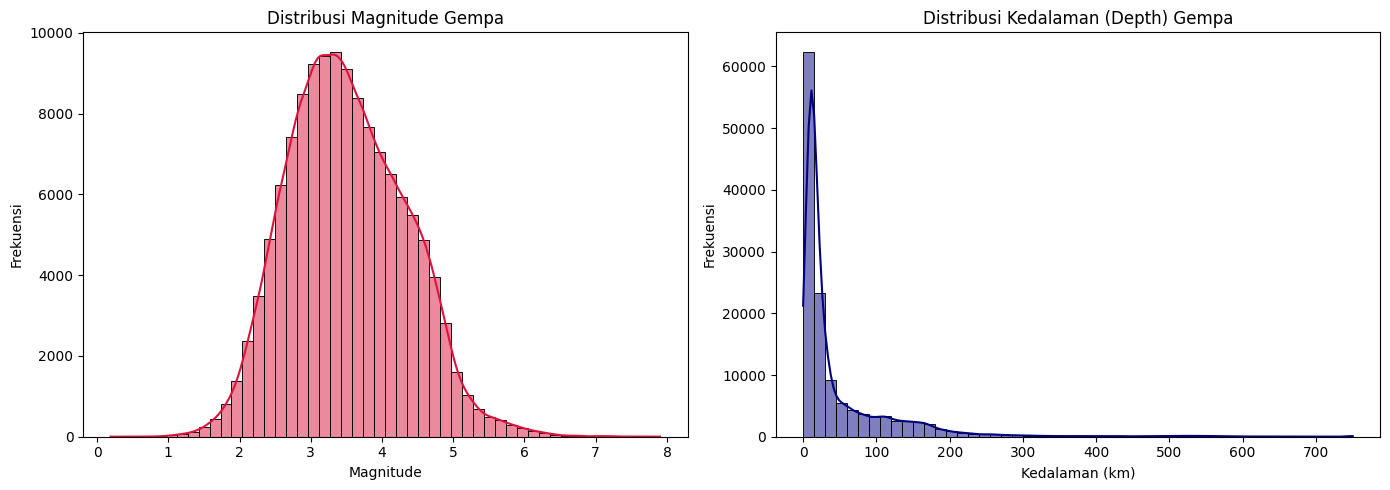

In [6]:
# 2 & 3. Distribusi Magnitude dan Depth
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram Magnitude
sns.histplot(df['mag'], bins=50, kde=True, ax=ax[0], color='crimson')
ax[0].set_title('Distribusi Magnitude Gempa')
ax[0].set_xlabel('Magnitude')
ax[0].set_ylabel('Frekuensi')

# Histogram Depth
sns.histplot(df['depth'], bins=50, kde=True, ax=ax[1], color='navy')
ax[1].set_title('Distribusi Kedalaman (Depth) Gempa')
ax[1].set_xlabel('Kedalaman (km)')
ax[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

## 3.2 Peta Sebaran Lokasi Gempa
Melihat klaster aktivitas seismik berdasarkan Latitude dan Longitude.

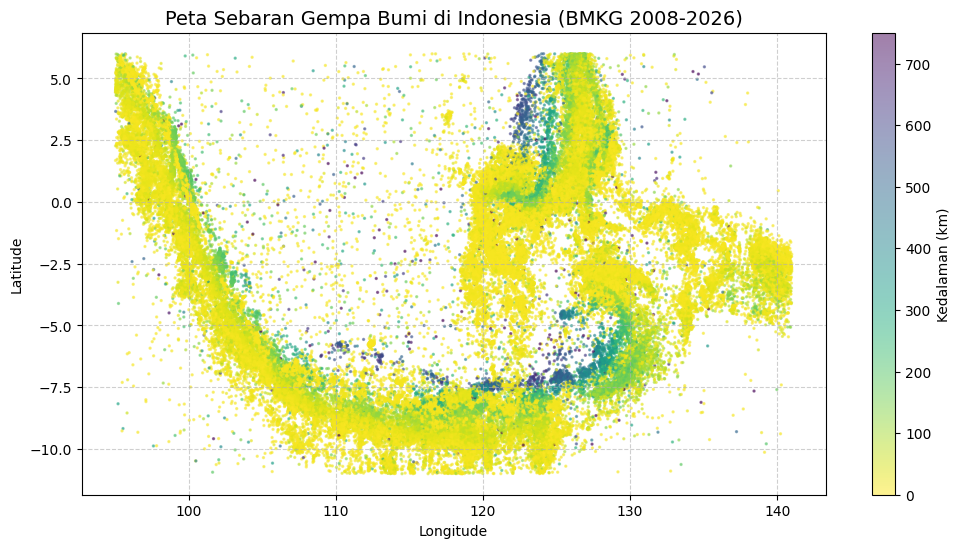

In [7]:
# 4. Peta Lokasi Gempa (Scatter Plot Latitude vs Longitude)
plt.figure(figsize=(12, 6))

# Menggunakan warna berdasarkan kedalaman (depth) untuk visualisasi yang lebih informatif
scatter = plt.scatter(df['longitude'], df['latitude'], 
                      c=df['depth'], cmap='viridis_r', 
                      alpha=0.5, s=2)

plt.colorbar(scatter, label='Kedalaman (km)')
plt.title('Peta Sebaran Gempa Bumi di Indonesia (BMKG 2008-2026)', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [8]:
df[['mag','depth']].describe()

,mag,depth
count,131117.000000,131117.000000
mean,3.512926,49.662500
std,0.830527,79.718405
min,0.191153,0.000000
25%,2.908607,10.000000
50%,3.452339,16.000000
75%,4.092886,54.000000
max,7.902198,750.000000


# 4. Feature Engineering & Preprocessing
Memilih fitur yang relevan untuk deteksi anomali, lalu melakukan standarisasi (*StandardScaler*) agar skala setiap fitur seragam dan tidak ada yang mendominasi saat dianalisis oleh algoritma Isolation Forest.

In [9]:
# 1. Pilih Fitur sesuai kriteria baru
features = ['mag', 'depth', 'latitude', 'longitude']
X = df[features]

# Statistik sebelum di-scale
print("Statistik SEBELUM di-scale:")
display(X.describe())

# 2. Standarisasi menggunakan StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Mengubah numpy array kembali ke DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

# Menampilkan Mean dan Standard Deviation SETELAH di-scale
print("\nMean setelah di-scale (harus mendekati 0):")
print(X_scaled_df.mean())
print("\nStandard Deviation setelah di-scale (harus mendekati 1):")
print(X_scaled_df.std())

Statistik SEBELUM di-scale:


,mag,depth,latitude,longitude
count,131117.000000,131117.000000,131117.000000,131117.000000
mean,3.512926,49.662500,-3.355570,119.279611
std,0.830527,79.718405,4.328986,10.745988
min,0.191153,0.000000,-10.999324,95.002388
25%,2.908607,10.000000,-7.831303,113.468903
50%,3.452339,16.000000,-2.840011,121.197647
75%,4.092886,54.000000,0.152680,126.837660
max,7.902198,750.000000,5.999397,140.998291



Mean setelah di-scale (harus mendekati 0):
mag         -2.080954e-16
depth        3.815082e-17
latitude     1.560715e-17
longitude   -7.161949e-16
dtype: float64

Standard Deviation setelah di-scale (harus mendekati 1):
mag          1.000004
depth        1.000004
latitude     1.000004
longitude    1.000004
dtype: float64


# 5. Anomaly Detection: Isolation Forest
Menerapkan algoritma Isolation Forest untuk memberikan label anomali secara otomatis. Kita akan membandingkan tingkat sensitivitas (*contamination*) `0.005` (0.5%) dan `0.01` (1%).

In [10]:
import joblib

# Menyiapkan parameter perbandingan
contaminations = [0.005, 0.01]
anomaly_labels = {}
anomaly_scores = {}

total_data = len(X_scaled_df)
print(f"1. Total Data Keseluruhan: {total_data}\n" + "-"*40)

for cont in contaminations:
    # Inisialisasi model dengan Random State 42
    iso_forest = IsolationForest(contamination=cont, random_state=42)
    
    # Fit & Predict (-1 untuk Anomali, 1 untuk Normal)
    labels = iso_forest.fit_predict(X_scaled_df)
    
    # Hitung Anomaly Score (semakin negatif = semakin anomali)
    scores = iso_forest.decision_function(X_scaled_df)
    
    # Simpan hasil untuk tiap contamination
    anomaly_labels[cont] = labels
    anomaly_scores[cont] = scores
    
    # Hitung statistik
    total_anomaly = (labels == -1).sum()
    total_normal = (labels == 1).sum()
    persentase_anomaly = (total_anomaly / total_data) * 100
    
    # Cetak output sesuai permintaan
    print(f"[ Hasil untuk Contamination {cont} ]")
    print(f"2. Total Normal   : {total_normal}")
    print(f"3. Total Anomaly  : {total_anomaly}")
    print(f"4. Persentase     : {persentase_anomaly:.2f}%\n")

# Menyimpan hasil contamination 0.005 (target utama proyek) ke dalam DataFrame
df['anomaly_label'] = anomaly_labels[0.005]
df['anomaly_score'] = anomaly_scores[0.005]

# Menyimpan anomaly score ke dalam folder yang sama
csv_path = '../Anomaly Detection BMKG/dataset_dengan_anomali.csv'
df.to_csv(csv_path, index=False)
print(f"Dataset beserta Anomaly Score (0.005) berhasil disimpan di: {csv_path}")

1. Total Data Keseluruhan: 131117
----------------------------------------
[ Hasil untuk Contamination 0.005 ]
2. Total Normal   : 130461
3. Total Anomaly  : 656
4. Persentase     : 0.50%

[ Hasil untuk Contamination 0.01 ]
2. Total Normal   : 129805
3. Total Anomaly  : 1312
4. Persentase     : 1.00%

Dataset beserta Anomaly Score (0.005) berhasil disimpan di: ../Anomaly Detection BMKG/dataset_dengan_anomali.csv


# 6. Analisis Hasil Anomali
Menganalisis hasil deteksi anomali (berdasarkan *contamination* 0.005) dengan melihat gempa-gempa paling ekstrem, membandingkan profil statistiknya dengan gempa normal, dan memvisualisasikannya di peta.

In [11]:
# 1. Menampilkan Top 20 Anomali paling ekstrem (berdasarkan Anomaly Score terendah)
top_20_anomali = df[df['anomaly_label'] == -1].sort_values('anomaly_score').head(20)
print("Top 20 Gempa Anomali Paling Ekstrem:")
display(top_20_anomali[['time', 'latitude', 'longitude', 'depth', 'mag', 'wilayah', 'anomaly_score']])

Top 20 Gempa Anomali Paling Ekstrem:


,time,latitude,longitude,depth,mag,wilayah,anomaly_score
67787,2019-12-24 17:02:34.147671+00:00,-4.490928,98.648064,718,5.483407,"Southwest of Sumatra, Indonesia",-0.083785
76362,2020-12-02 04:07:55.595829+00:00,3.177634,95.931435,470,5.556558,Off West Coast of Northern Sumatra,-0.081175
70790,2020-04-25 03:07:34.125117+00:00,4.971163,129.636948,685,7.001108,"North of Halmahera, Indonesia",-0.080767
74437,2020-09-24 04:33:59.751608+00:00,3.712339,99.381149,420,5.861750,"Northern Sumatra, Indonesia",-0.079555
78143,2021-02-12 13:57:57.380247+00:00,-10.481013,100.470833,415,5.661607,"Southwest of Sumatra, Indonesia",-0.079132
77181,2021-01-03 12:47:34.339066+00:00,5.277691,134.276138,750,5.106116,"W. Caroline Islands, Micronesia",-0.075024
73733,2020-08-22 15:39:31.256282+00:00,1.555192,109.467720,750,6.261151,Borneo,-0.074582
70903,2020-04-30 03:21:20.803376+00:00,5.177471,134.643448,750,5.096391,"W. Caroline Islands, Micronesia",-0.074530
79644,2021-04-04 16:39:51.727342+00:00,-9.614478,113.612663,654,5.700275,"South of Java, Indonesia",-0.071516
71159,2020-05-11 16:14:21.537701+00:00,2.718135,105.523766,630,5.276988,South China Sea,-0.070938


In [12]:
# 2. Perbandingan statistik (describe) antara Normal (1) dan Anomaly (-1)
print("Statistik Gempa NORMAL:")
display(df[df['anomaly_label'] == 1][['mag', 'depth', 'latitude', 'longitude']].describe())

print("\nStatistik Gempa ANOMALI:")
display(df[df['anomaly_label'] == -1][['mag', 'depth', 'latitude', 'longitude']].describe())

Statistik Gempa NORMAL:


,mag,depth,latitude,longitude
count,130461.000000,130461.000000,130461.000000,130461.000000
mean,3.506207,47.176060,-3.371485,119.286537
std,0.825665,71.097088,4.319733,10.751674
min,0.191153,0.000000,-10.999324,95.002388
25%,2.906165,10.000000,-7.839256,113.502930
50%,3.447339,16.000000,-2.845117,121.191658
75%,4.083470,52.000000,0.127442,126.845619
max,7.902198,750.000000,5.999397,140.998291



Statistik Gempa ANOMALI:


,mag,depth,latitude,longitude
count,656.000000,656.000000,656.000000,656.000000
mean,4.849304,544.149390,-0.190614,117.902232
std,0.704979,138.623392,4.962330,9.455032
min,2.792341,145.000000,-10.945748,95.015739
25%,4.376863,482.000000,-5.470898,110.688604
50%,4.753266,548.000000,2.042081,122.455187
75%,5.320450,626.250000,3.920708,123.751947
max,7.272894,750.000000,5.998806,139.260055


In [13]:
# 3. Tabel perbandingan rata-rata (Mean) Normal vs Anomali
mean_comparison = df.groupby('anomaly_label')[['mag', 'depth', 'latitude', 'longitude']].mean().reset_index()
mean_comparison['anomaly_label'] = mean_comparison['anomaly_label'].map({1: 'Normal', -1: 'Anomali'})

print("Perbandingan Rata-rata (Mean) Normal vs Anomali:")
display(mean_comparison)

Perbandingan Rata-rata (Mean) Normal vs Anomali:


,anomaly_label,mag,depth,latitude,longitude
0,Anomali,4.849304,544.14939,-0.190614,117.902232
1,Normal,3.506207,47.17606,-3.371485,119.286537


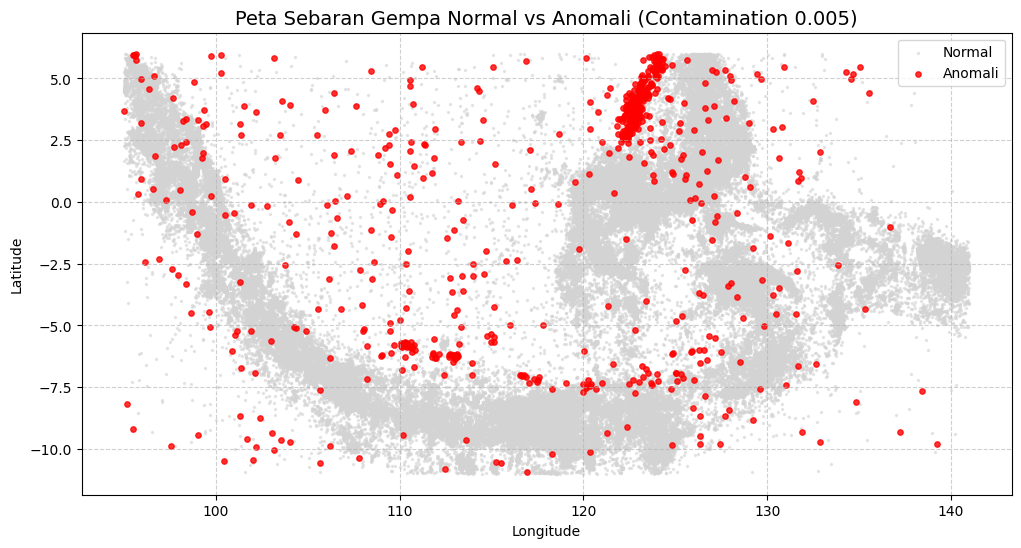

In [14]:
# 4. Visualisasi Longitude vs Latitude (Normal = Abu-abu, Anomali = Merah)
plt.figure(figsize=(12, 6))

# Plot data normal (abu-abu, transparan, ukuran kecil)
normal_data = df[df['anomaly_label'] == 1]
plt.scatter(normal_data['longitude'], normal_data['latitude'], 
            c='lightgray', alpha=0.5, s=2, label='Normal')

# Plot data anomali (merah, ukuran lebih besar)
anomaly_data = df[df['anomaly_label'] == -1]
plt.scatter(anomaly_data['longitude'], anomaly_data['latitude'], 
            c='red', alpha=0.8, s=15, label='Anomali')

plt.title('Peta Sebaran Gempa Normal vs Anomali (Contamination 0.005)', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 6.1 Analisis Lanjutan: Korelasi & Batas Ekstrem (Quantile)
Memeriksa hubungan linier antara kekuatan gempa (magnitude) dan kedalaman (depth) khusus pada kelompok anomali, serta melihat distribusi ekstrem (persentil atas) kedalaman pada kelompok normal.

In [15]:
# 1. Korelasi Magnitude dan Depth pada Gempa Anomali
print("Korelasi (Hubungan Linier) antara Magnitude dan Depth pada Gempa ANOMALI:")
display(anomaly_data[['mag', 'depth']].corr())

# 2. Nilai Quantile (Persentil) Depth pada Gempa Normal
print("\nBatas Kedalaman (Depth) pada Gempa NORMAL (Quantile 90%, 95%, 99%):")
display(normal_data['depth'].quantile([0.90, 0.95, 0.99]))

Korelasi (Hubungan Linier) antara Magnitude dan Depth pada Gempa ANOMALI:


,mag,depth
mag,1.000000,-0.325662
depth,-0.325662,1.000000



Batas Kedalaman (Depth) pada Gempa NORMAL (Quantile 90%, 95%, 99%):


0.90    134.0
0.95    176.0
0.99    358.0
Name: depth, dtype: float64

## 6.2 Konversi Label & Analisis Wilayah / Normalitas
Mengubah format label bawaan Isolation Forest agar sesuai dengan format standar Machine Learning klasifikasi biner (`0` = Normal, `1` = Anomali). Selain itu, kita akan melihat profil gempa yang dianggap "paling normal" dan wilayah mana yang paling banyak memiliki kejadian anomali.

In [16]:
# 1. Konversi Label: 1 (Normal bawaan IF) -> 0, -1 (Anomali bawaan IF) -> 1
df['anomaly_label'] = df['anomaly_label'].map({1: 0, -1: 1})

# Update variabel pembantu agar sinkron dengan data terbaru
anomaly_data = df[df['anomaly_label'] == 1]
normal_data = df[df['anomaly_label'] == 0]

print("Pengecekan konversi label:")
print(df['anomaly_label'].value_counts().rename(index={0: "Normal (0)", 1: "Anomali (1)"}))

Pengecekan konversi label:
anomaly_label
Normal (0)     130461
Anomali (1)       656
Name: count, dtype: int64


In [17]:
# 2. Menampilkan Top 20 Gempa PALING NORMAL (berdasarkan Anomaly Score tertinggi)
# Semakin positif skornya, semakin "biasa/normal" profil gempa tersebut menurut pola IF
top_20_normal = normal_data.sort_values('anomaly_score', ascending=False).head(20)

print("Top 20 Gempa Paling NORMAL (Skor Tertinggi):")
display(top_20_normal[['time', 'latitude', 'longitude', 'depth', 'mag', 'wilayah', 'anomaly_score']])

Top 20 Gempa Paling NORMAL (Skor Tertinggi):


,time,latitude,longitude,depth,mag,wilayah,anomaly_score
10576,2011-02-15 16:47:30.843086+00:00,-2.575339,121.653670,10,3.099087,"Sulawesi, Indonesia",0.281308
72786,2020-07-22 19:18:44.501161+00:00,-2.471370,121.457077,10,3.114758,"Sulawesi, Indonesia",0.280884
10624,2011-02-17 15:53:13.029325+00:00,-2.492333,121.461430,10,3.122736,"Sulawesi, Indonesia",0.280884
70773,2020-04-24 11:52:10.084955+00:00,-2.624211,121.722115,10,3.132505,"Sulawesi, Indonesia",0.280852
102943,2023-04-30 23:08:29.585289+00:00,-2.597257,121.861260,10,3.124786,"Sulawesi, Indonesia",0.280763
125925,2025-06-29 07:37:49.847696+00:00,-2.572981,121.767754,10,3.140341,"Sulawesi, Indonesia",0.280738
59725,2019-04-14 14:10:36.813758+00:00,-2.388287,123.262894,10,3.255869,"Sulawesi, Indonesia",0.280604
118426,2025-01-30 06:06:31.022938+00:00,-2.481287,121.487846,10,3.096503,"Sulawesi, Indonesia",0.280442
94073,2022-07-29 20:59:42.867989+00:00,-2.516826,122.484589,10,3.218061,"Sulawesi, Indonesia",0.280302
94075,2022-07-29 21:12:29.439299+00:00,-2.512165,122.601562,10,3.157328,"Sulawesi, Indonesia",0.280297


In [18]:
# 3. Konsentrasi Gempa Anomali Berdasarkan Wilayah
print("Sebaran Wilayah Kejadian Gempa ANOMALI (Top 15 Terbanyak):")
display(anomaly_data['wilayah'].value_counts().head(15))

Sebaran Wilayah Kejadian Gempa ANOMALI (Top 15 Terbanyak):


wilayah
Celebes Sea                        193
Java Sea                            50
Mindanao, Philippines               48
Borneo                              42
Banda Sea                           36
Java, Indonesia                     34
Northern Sumatra, Indonesia         26
Southwest of Sumatra, Indonesia     26
South China Sea                     20
Southern Sumatra, Indonesia         19
Flores Sea                          16
Minahassa Peninsula, Sulawesi       12
Irian Jaya Region, Indonesia        12
Malay Peninsula                     11
Northern Molucca Sea                10
Name: count, dtype: int64

## 6.3 Visualisasi Distribusi: Boxplot
Menggunakan *boxplot* untuk membandingkan secara jelas bagaimana sebaran nilai tengah (median), kuartil, dan pencilan (*outliers*) antara gempa Normal dan gempa Anomali pada fitur **Magnitude** dan **Depth**.

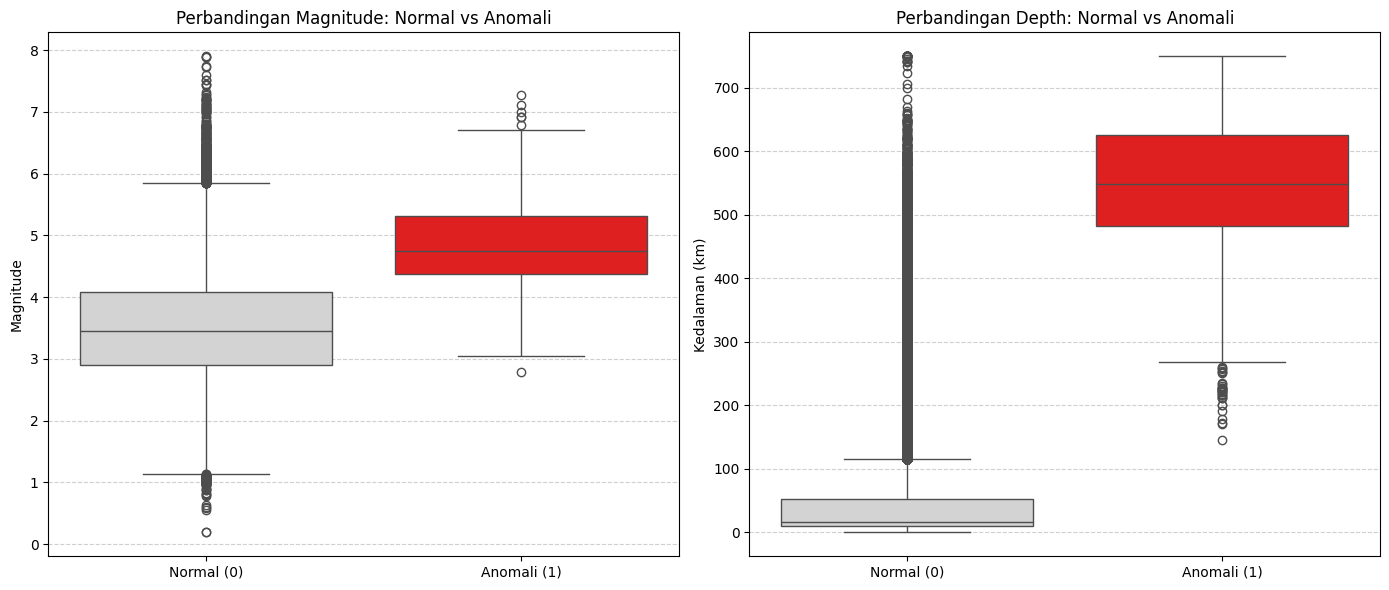

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Mengganti label angka menjadi teks khusus untuk visualisasi agar lebih mudah dibaca
plot_df = df.copy()
plot_df['Kategori'] = plot_df['anomaly_label'].map({0: 'Normal (0)', 1: 'Anomali (1)'})

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Boxplot Magnitude
sns.boxplot(x='Kategori', y='mag', data=plot_df, ax=ax[0], palette=['lightgray', 'red'])
ax[0].set_title('Perbandingan Magnitude: Normal vs Anomali', fontsize=12)
ax[0].set_xlabel('')
ax[0].set_ylabel('Magnitude')
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# 2. Boxplot Depth
sns.boxplot(x='Kategori', y='depth', data=plot_df, ax=ax[1], palette=['lightgray', 'red'])
ax[1].set_title('Perbandingan Depth: Normal vs Anomali', fontsize=12)
ax[1].set_xlabel('')
ax[1].set_ylabel('Kedalaman (km)')
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [20]:
import pickle
import joblib

# Menyimpan model XGBoost (Asumsi nama variabel Anda adalah xgb_model, xgb_clf, atau model_xgb)
# Silakan hapus tanda pagar (#) pada baris yang sesuai dengan nama variabel Anda:

try:
    with open('model_xgboost.pkl', 'wb') as f:
        pickle.dump(xgb_model, f) # Ganti xgb_model jika nama variabel XGBoost Anda berbeda
    print("Model XGBoost berhasil disimpan!")
except NameError:
    print("Variabel model XGBoost tidak ditemukan. Pastikan Anda sudah merun cell training XGBoost.")


# Menyimpan model Isolation Forest (Asumsi nama variabel Anda adalah if_model, iso_forest, atau model_if)
# Silakan hapus tanda pagar (#) pada baris yang sesuai dengan nama variabel Anda:

try:
    with open('model_isolation_forest.pkl', 'wb') as f:
        pickle.dump(if_model, f) # Ganti if_model jika nama variabel Isolation Forest Anda berbeda
    print("Model Isolation Forest berhasil disimpan!")
except NameError:
    print("Variabel model Isolation Forest tidak ditemukan. Pastikan Anda sudah merun cell training Isolation Forest.")


Variabel model XGBoost tidak ditemukan. Pastikan Anda sudah merun cell training XGBoost.
Variabel model Isolation Forest tidak ditemukan. Pastikan Anda sudah merun cell training Isolation Forest.


In [21]:
import pickle

# Melatih ulang model khusus untuk target utama (0.005) agar kita menyimpan model yang tepat
# (Karena sebelumnya di dalam loop, variabel iso_forest terganti oleh model 0.01 di iterasi terakhir)
final_iso_forest = IsolationForest(contamination=0.005, random_state=42)
final_iso_forest.fit(X_scaled_df)

nama_file = 'isolation_forest_bmkg.pkl'
with open(nama_file, 'wb') as f:
    pickle.dump(final_iso_forest, f)

print(f"Model Isolation Forest (contamination=0.005) berhasil disimpan dengan nama: {nama_file}!")

Model Isolation Forest (contamination=0.005) berhasil disimpan dengan nama: isolation_forest_bmkg.pkl!


In [22]:
# import folium

# # 1. Membuat Peta Dasar (Base Map) 
# peta_anomali = folium.Map(location=[-0.7893, 113.9213], zoom_start=5, tiles='OpenStreetMap')

# # 2. Memasukkan titik-titik ANOMALI ke dalam peta
# for idx, row in anomaly_data.iterrows():
#     folium.CircleMarker(
#         location=[row['latitude'], row['longitude']], 
#         radius=2,                                      
#         color='red',                                   
#         fill=True,
#         fill_color='red',                              
#         fill_opacity=0.7,
#         tooltip=f"Wilayah: {row['wilayah']}<br>Mag: {row['mag']}<br>Depth: {row['depth']} km"
#     ).add_to(peta_anomali)

# # 3. MENYIMPAN PETA KE DALAM FILE HTML (Tidak ditampilkan di dalam VS Code)
# peta_anomali.save('peta_anomali_gempa.html')
# print("✅ Peta interaktif berhasil disimpan!")
# print("Silakan buka folder proyek Anda dan klik ganda file 'peta_anomali_gempa.html'")


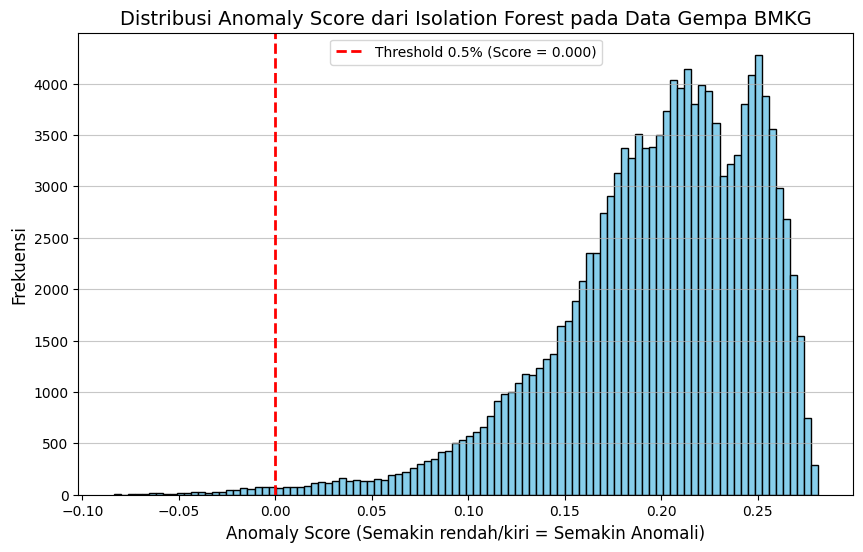

In [23]:
import matplotlib.pyplot as plt

# Asumsi model Anda bernama 'model' atau 'iso_forest'
# Dapatkan anomaly score dari model. (Semakin negatif/kecil nilainya, semakin anomali di scikit-learn)
scores = df['anomaly_score']

plt.figure(figsize=(10, 6))
# Plot histogram dengan bins yang rapat
plt.hist(scores, bins=100, color='skyblue', edgecolor='black')

# Hitung nilai threshold berdasarkan persentil 0.5% (0.005)
threshold = scores.quantile(0.005)

# Gambar garis batas threshold
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, 
            label=f'Threshold 0.5% (Score = {threshold:.3f})')

plt.title('Distribusi Anomaly Score dari Isolation Forest pada Data Gempa BMKG', fontsize=14)
plt.xlabel('Anomaly Score (Semakin rendah/kiri = Semakin Anomali)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.7)
plt.show()
